# 1D DoubleWell Benchmark Results

This notebook inspects one analyzed 1D direct-sampling system at a time.
Set `SYSTEM_KEY` in the first code cell, or pass `BENCHMARK_SYSTEM_ROOT` / `BENCHMARK_SYSTEM_KEY` in the environment before executing the notebook.

In [1]:
import csv
import json
import os
from pathlib import Path

from IPython.display import HTML, Image, Markdown, display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

SYSTEM_OPTIONS = {
    "k1_e10": "DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0",
    "k0p5_e10": "DoubleWell__k0_0p5__x0_m10p0__k1_0p5__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0",
    "k1_e1": "DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_1p0__kT_1p0__dt_0p0005__gamma_1p0",
}

SYSTEM_KEY = os.environ.get("BENCHMARK_SYSTEM_KEY", "k1_e10")
SYSTEM_ROOT_ENV = os.environ.get("BENCHMARK_SYSTEM_ROOT")
if SYSTEM_ROOT_ENV:
    SYSTEM_ROOT = Path(SYSTEM_ROOT_ENV).resolve()
else:
    SYSTEM_ROOT = (REPO_ROOT / "data" / "1D" / SYSTEM_OPTIONS[SYSTEM_KEY]).resolve()

display(Markdown(f"**Selected system:** `{SYSTEM_ROOT.name}`"))

**Selected system:** `DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0`

In [2]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)

def read_text(path: Path):
    return path.read_text(encoding="utf-8")

def read_csv_rows(path: Path):
    if not path.exists():
        return []
    with path.open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))

def render_table(rows, columns=None):
    if not rows:
        display(Markdown("_No rows found._"))
        return
    if columns is None:
        columns = list(rows[0].keys())
    head = "".join(f"<th>{col}</th>" for col in columns)
    body = []
    for row in rows:
        body.append("<tr>" + "".join(f"<td>{row.get(col, '')}</td>" for col in columns) + "</tr>")
    html = "<table><thead><tr>" + head + "</tr></thead><tbody>" + "".join(body) + "</tbody></table>"
    display(HTML(html))

def show_figure(path: Path, title: str):
    display(Markdown(f"### {title}"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"_Missing figure:_ `{path}`"))

RUN_CONTEXT = load_json(SYSTEM_ROOT / "run_context.json")
SELECTION = load_json(SYSTEM_ROOT / "benchmark" / "selected" / "selection.json")
SUMMARY_TEXT = read_text(SYSTEM_ROOT / "benchmark" / "selected" / "summary.dat")
US_RANKING = read_csv_rows(SYSTEM_ROOT / "US" / "rankings" / "all.csv")
AUS_RANKING = read_csv_rows(SYSTEM_ROOT / "AUS" / "rankings" / "all.csv")
NES_RANKING = read_csv_rows(SYSTEM_ROOT / "NES" / "rankings" / "all.csv")
MINES_RANKING = read_csv_rows(SYSTEM_ROOT / "MINES" / "rankings" / "all.csv")
MTD_RANKING = read_csv_rows(SYSTEM_ROOT / "MTD" / "rankings" / "all.csv")
FIGURES_ROOT = SYSTEM_ROOT / "benchmark" / "figures"
GIFS_ROOT = SYSTEM_ROOT / "benchmark" / "gifs"


In [3]:
pot = RUN_CONTEXT["potential"]
display(Markdown("## System Summary"))
display(Markdown(
    f"Potential: `k0={pot['k0']}`, `x0={pot['x0']}`, `k1={pot['k1']}`, `x1={pot['x1']}`, `E1={pot['E1']}`  \n"
    f"Dynamics: `kT={RUN_CONTEXT['thermal_kT']}`, `dt={RUN_CONTEXT['dt']}`, `gamma={RUN_CONTEXT['gamma']}`  \n"
    f"RMSE grid: `[{RUN_CONTEXT['rmse_eval_grid']['xmin']}, {RUN_CONTEXT['rmse_eval_grid']['xmax']}]` with `dx={RUN_CONTEXT['rmse_eval_grid']['dx']}`"
))
display(Markdown("## Selected Best Combinations"))
display(Markdown(
    f"- US: `{SELECTION['US']['label']}`\n"
    f"- AUS: `{SELECTION['AUS']['label']}`\n"
    f"- NES: `{SELECTION['NES']['label']}`\n"
    f"- MINES: `{SELECTION['MINES']['label']}`\n"
    f"- MTD: `{SELECTION['MTD']['label']}`"
))
display(Markdown("## Text Summary"))
display(Markdown(f"```text\n{SUMMARY_TEXT}\n```"))


## System Summary

Potential: `k0=1.0`, `x0=-10.0`, `k1=1.0`, `x1=10.0`, `E1=10.0`  
Dynamics: `kT=1.0`, `dt=0.0005`, `gamma=1.0`  
RMSE grid: `[-10.0, 10.0]` with `dx=0.2`

## Selected Best Combinations

- US: `k_50p0__dx_0p5`
- AUS: `qnext_0p95__alpha_3p0__fit_poly_4term_parent__kmin_1p0__kmax_50p0`
- NES: `k_10p0`
- MINES: `k_pull_5p0`
- MTD: `biasfactor_10p0`

## Text Summary

```text
1D DoubleWell benchmark summary

System construction
name: double-well
k0: 1.0
x0: -10.0
k1: 1.0
x1: 10.0
E1: 10.0

Shared dynamics settings
thermal_kT: 1.0
dt: 0.0005
gamma: 1.0
PMF grid: x in [-12.0, 12.0] with dx=0.1
RMSE evaluation grid: x in [-10.0, 10.0] with dx=0.2
replicate seeds: 101
time grid (step units): 10000, 14100, 20000, 28200, 39800, 56200, 79400, 112200, 158500, 223900, 316200, 446700, 631000, 891300, 1258900, 1778300, 2511900, 3548100, 5011900, 7079500, 10000000

US screen
k values: 5.0, 10.0, 20.0, 50.0
dx values: 0.5
total_steps per combo: 10000000
saved sample stride: 1000 steps

AUS screen
q_next values: 0.95
alpha values: 3.0
fit methods: poly_4term_parent
k_min values: 1.0
k_max values: 50.0
frontier grid dx: 0.05
start_x_left: -10.0
start_x_right: 10.0
endpoint k: 1.0
eq_steps per adaptive window: 100000
eq_nout per adaptive window: 1000
total_steps per combo: 10000000
PMF analysis tail fraction per adaptive window: 0.9
placement rule: grow one left child and one right child each iteration; the left child uses q_next(parent samples), the right child uses q_{1-next}(parent samples), and each child center is placed from the parent median and alpha
k rule: estimate F' from a cubic polynomial fit over the entire PMF reconstructed from the parent umbrella only, excluding all ancestor windows; the left child derives k only when F'(q_next) > 0, the right child derives k only when F'(q_{1-next}) < 0, otherwise the child is placed at the target quantile with k_min
stop rule: stop before launching the next pair when q^m_{next,left} > q^m_{1-next,right}
post-match refine metric: lowest_bin_ess
post-match cubic-fit half-width: 5 grid points
post-match k_addition: 10.0
post-match ESS threshold before redistribution: 0.05
post-match budget rule: once the frontiers meet, keep adding rescue umbrellas from the current lowest-ESS matched-region point; once all resolved bins exceed the ESS threshold, split the remaining budget across the allocated umbrella set
max_iterations: 50

NES screen
k values: 0.1, 1.0, 5.0, 10.0
eq_steps: 10000
eq_nout: 1000
n_traj_per_direction: 50
neq_nout per switching trajectory: 1000
k_midscale: 1.0

MINES screen
k_pull values: 1.0, 5.0, 10.0
frontier grid dx: 0.05
eq_steps: 10000
eq_nout: 1000
n_traj_per_direction: 25
t_neq: 10000
neq_nout: 1000
ESS_min: 20
overlap_min: 0.1
work_overlap_min: 0.05
max_depth_per_side: 10

WT-MTD screen
biasfactor values: 10.0, 100.0, 1000.0, 10000.0
total_steps: 10000000
per_walker_steps: 5000000
saved sample stride: 1000 steps
w0: 4.0
sigma: 0.8
stride: 1000

Selection rule
1. Prefer combinations with at least 95% finite coverage on the central x region.
2. Rank surviving combinations by lowest final-time RMSE to the analytic 1D PMF.
3. Break ties using lower final mean variance and then lower time-averaged RMSE.

Selected benchmark-facing files
us.dat -> k_50p0__dx_0p5
aus.dat -> qnext_0p95__alpha_3p0__fit_poly_4term_parent__kmin_1p0__kmax_50p0
nes.dat -> k_10p0
mines.dat -> k_pull_5p0
mtd.dat -> biasfactor_10p0

Streaming cleanup policy
US and MTD keep only processed PMFs, method metadata, one 1000-sample reduced trajectory file per seed, and selected GIFs.
AUS keeps processed PMFs plus one reduced adaptive-window trajectory file per seed.
NES keeps processed PMFs for every target budget and a 1000-sample reduced trajectory file only for the longest switching-time case.
MINES keeps processed PMFs plus reduced milestone/work summaries rather than all raw switching trajectories.

Filesystem layout
system root: /Users/shuyuchen/Dropbox/ETH/Work/ellipse-bias-noneq-sim/data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0
US seed PMFs: US/<combo>/processed/seed_<seed>.dat
AUS seed PMFs: AUS/<combo>/processed/seed_<seed>.dat
NES seed PMFs: NES/<combo>/processed/seed_<seed>.dat
MINES seed PMFs: MINES/<combo>/processed/seed_<seed>.dat
MTD seed PMFs: MTD/<combo>/processed/seed_<seed>.dat
benchmark outputs: benchmark/selected/{us,aus,nes,mines,mtd}.dat
benchmark figures: benchmark/figures/
benchmark gifs: benchmark/gifs/

US ranking rows
k_50p0__dx_0p5: rmse=4.333531, coverage=0.980, selected=true
k_20p0__dx_0p5: rmse=1.938208, coverage=0.960, selected=false
k_10p0__dx_0p5: rmse=1.607157, coverage=0.911, selected=false
k_5p0__dx_0p5: rmse=3.770670, coverage=0.832, selected=false

AUS ranking rows
qnext_0p95__alpha_3p0__fit_poly_4term_parent__kmin_1p0__kmax_50p0: rmse=0.405181, coverage=0.970, selected=true

NES ranking rows
k_10p0: rmse=6.386375, coverage=1.000, selected=true
k_5p0: rmse=6.435621, coverage=1.000, selected=false
k_1p0: rmse=6.773340, coverage=0.822, selected=false
k_0p1: rmse=7.061873, coverage=0.327, selected=false

MINES ranking rows
k_pull_5p0: rmse=12.427361, coverage=1.000, selected=true
k_pull_10p0: rmse=16.645883, coverage=1.000, selected=false
k_pull_1p0: rmse=6.522540, coverage=0.752, selected=false

MTD ranking rows
biasfactor_10p0: rmse=12.248631, coverage=1.000, selected=true
biasfactor_1000p0: rmse=60.513703, coverage=1.000, selected=false
biasfactor_100p0: rmse=60.666899, coverage=1.000, selected=false
biasfactor_10000p0: rmse=67.394940, coverage=1.000, selected=false

```

In [4]:
display(Markdown("## Parameter Screening Tables"))
display(Markdown("### US screening"))
render_table(US_RANKING, ["label", "k", "dx", "final_rmse", "time_avg_rmse", "central_coverage_fraction", "selected"])
display(Markdown("### AUS screening"))
render_table(AUS_RANKING, ["label", "k", "final_rmse", "time_avg_rmse", "central_coverage_fraction", "selected"])
display(Markdown("### NES screening"))
render_table(NES_RANKING, ["label", "k", "final_rmse", "time_avg_rmse", "central_coverage_fraction", "selected"])
display(Markdown("### MINES screening"))
render_table(MINES_RANKING, ["label", "k_pull", "final_rmse", "time_avg_rmse", "central_coverage_fraction", "selected"])
display(Markdown("### MTD screening"))
render_table(MTD_RANKING, ["label", "biasfactor", "final_rmse", "time_avg_rmse", "central_coverage_fraction", "selected"])


## Parameter Screening Tables

### US screening

label,k,dx,final_rmse,time_avg_rmse,central_coverage_fraction,selected
k_50p0__dx_0p5,50.0,0.5,4.333530802843784,19.350662079711952,0.9801980198019802,true
k_20p0__dx_0p5,20.0,0.5,1.9382083782954467,16.73080004720484,0.9603960396039604,false
k_10p0__dx_0p5,10.0,0.5,1.6071565431191992,15.124711164702376,0.9108910891089109,false
k_5p0__dx_0p5,5.0,0.5,3.7706700843596814,18.309383824174912,0.8316831683168316,false


### AUS screening

_No rows found._

...

label,k,final_rmse,time_avg_rmse,central_coverage_fraction,selected
k_10p0,10.0,6.386375383685099,31.003136027211017,1.0,true
k_5p0,5.0,6.435620706663462,34.78906515134217,1.0,false
k_1p0,1.0,6.7733396264737165,7.52636623951434,0.8217821782178217,false
k_0p1,0.1,7.061873060804168,6.854990367486154,0.32673267326732675,false


### MINES screening

label,k_pull,final_rmse,time_avg_rmse,central_coverage_fraction,selected
k_pull_5p0,5.0,12.427361264787677,12.427361264787677,1.0,true
k_pull_10p0,10.0,16.645882743200662,16.645882743200662,1.0,false
k_pull_1p0,1.0,6.522539598084001,6.522539598084001,0.7524752475247525,false


### MTD screening

label,biasfactor,final_rmse,time_avg_rmse,central_coverage_fraction,selected
biasfactor_10p0,10.0,12.248631262719034,26.82649975992178,1.0,true
biasfactor_1000p0,1000.0,60.513703094685724,43.261928673699906,1.0,false
biasfactor_100p0,100.0,60.66689861399274,35.110036580869554,1.0,false
biasfactor_10000p0,10000.0,67.39494028878782,38.245909689053164,1.0,false


In [5]:
FIGURES_ROOT

PosixPath('/Users/shuyuchen/Dropbox/ETH/Work/ellipse-bias-noneq-sim/data/1D/DoubleWell__k0_1p0__x0_m10p0__k1_1p0__x1_10p0__E1_10p0__kT_1p0__dt_0p0005__gamma_1p0/benchmark/figures')

## Convergence Figures

### US: RMSE vs time across screened parameters

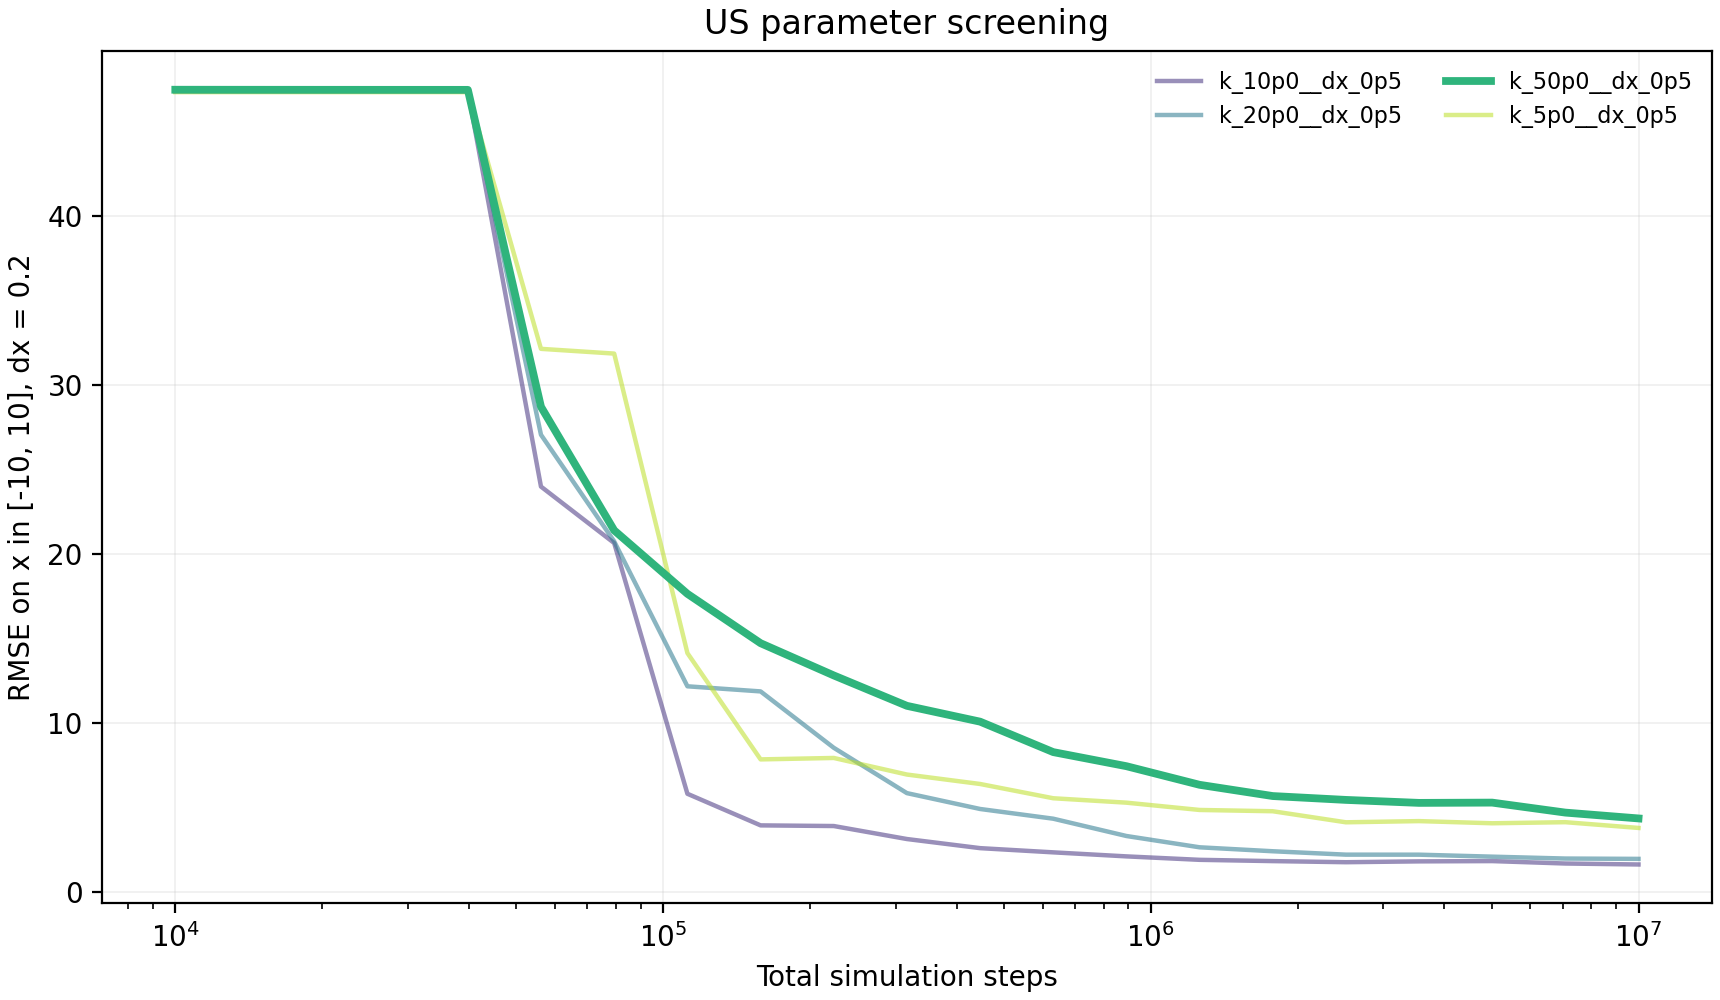

### AUS: RMSE vs time across screened parameters

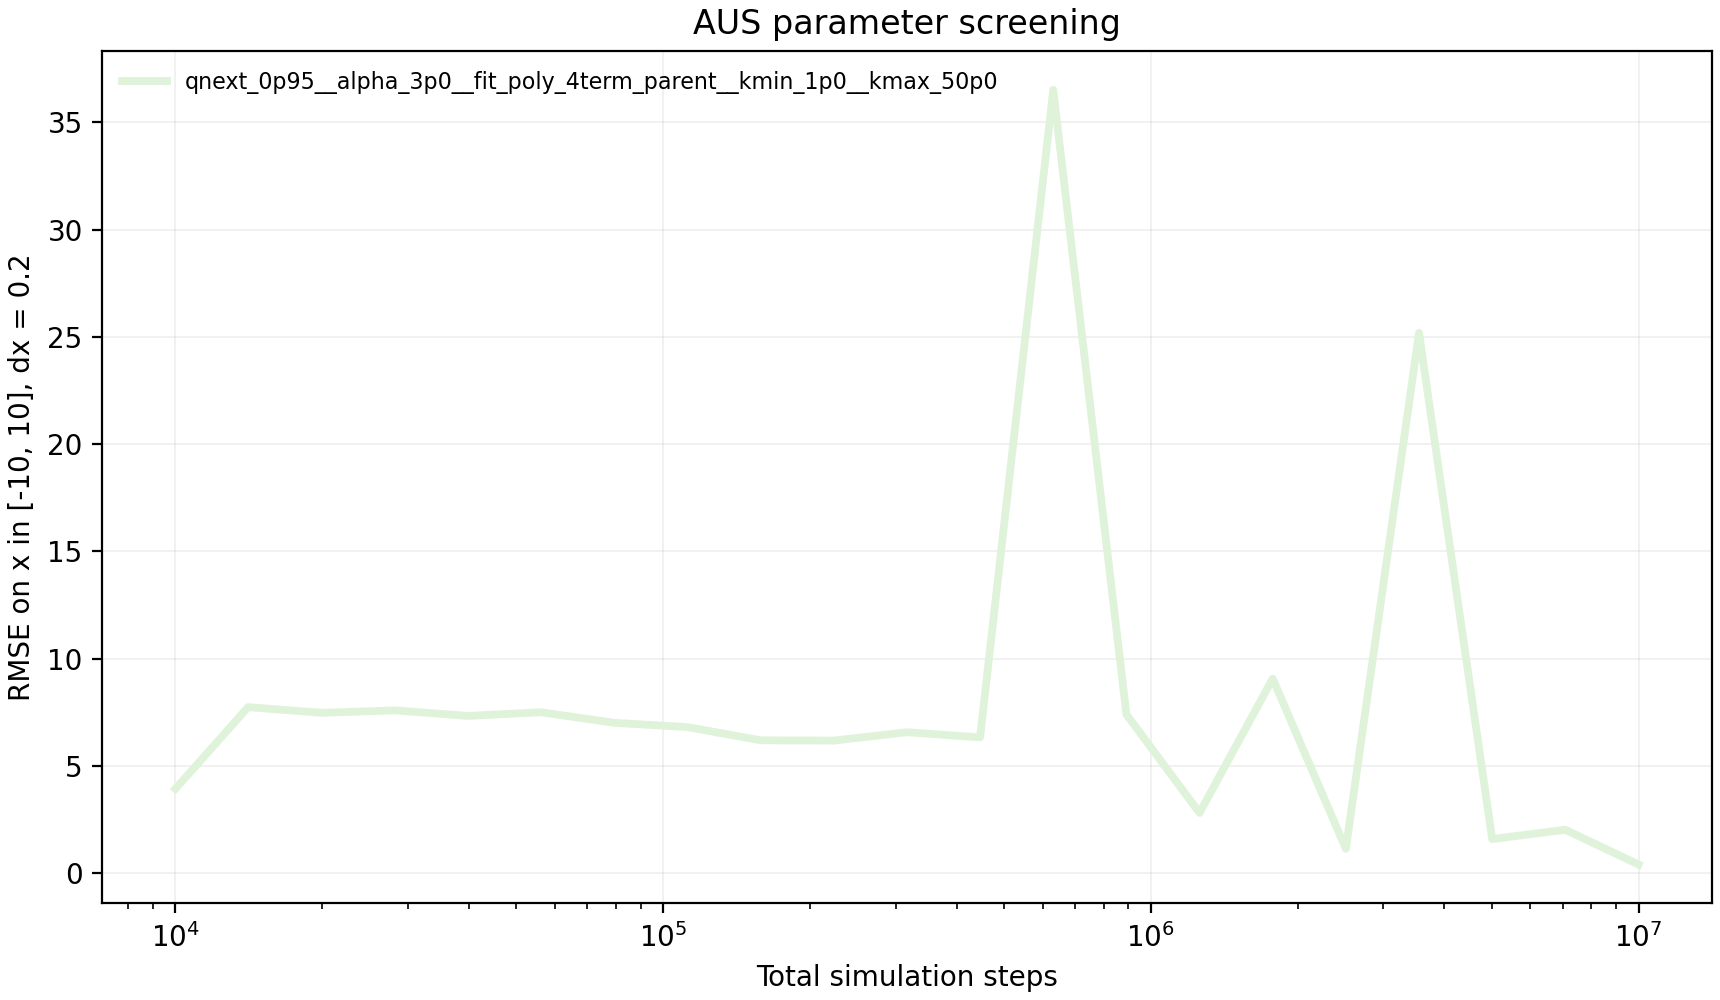

### NES: RMSE vs time across screened parameters

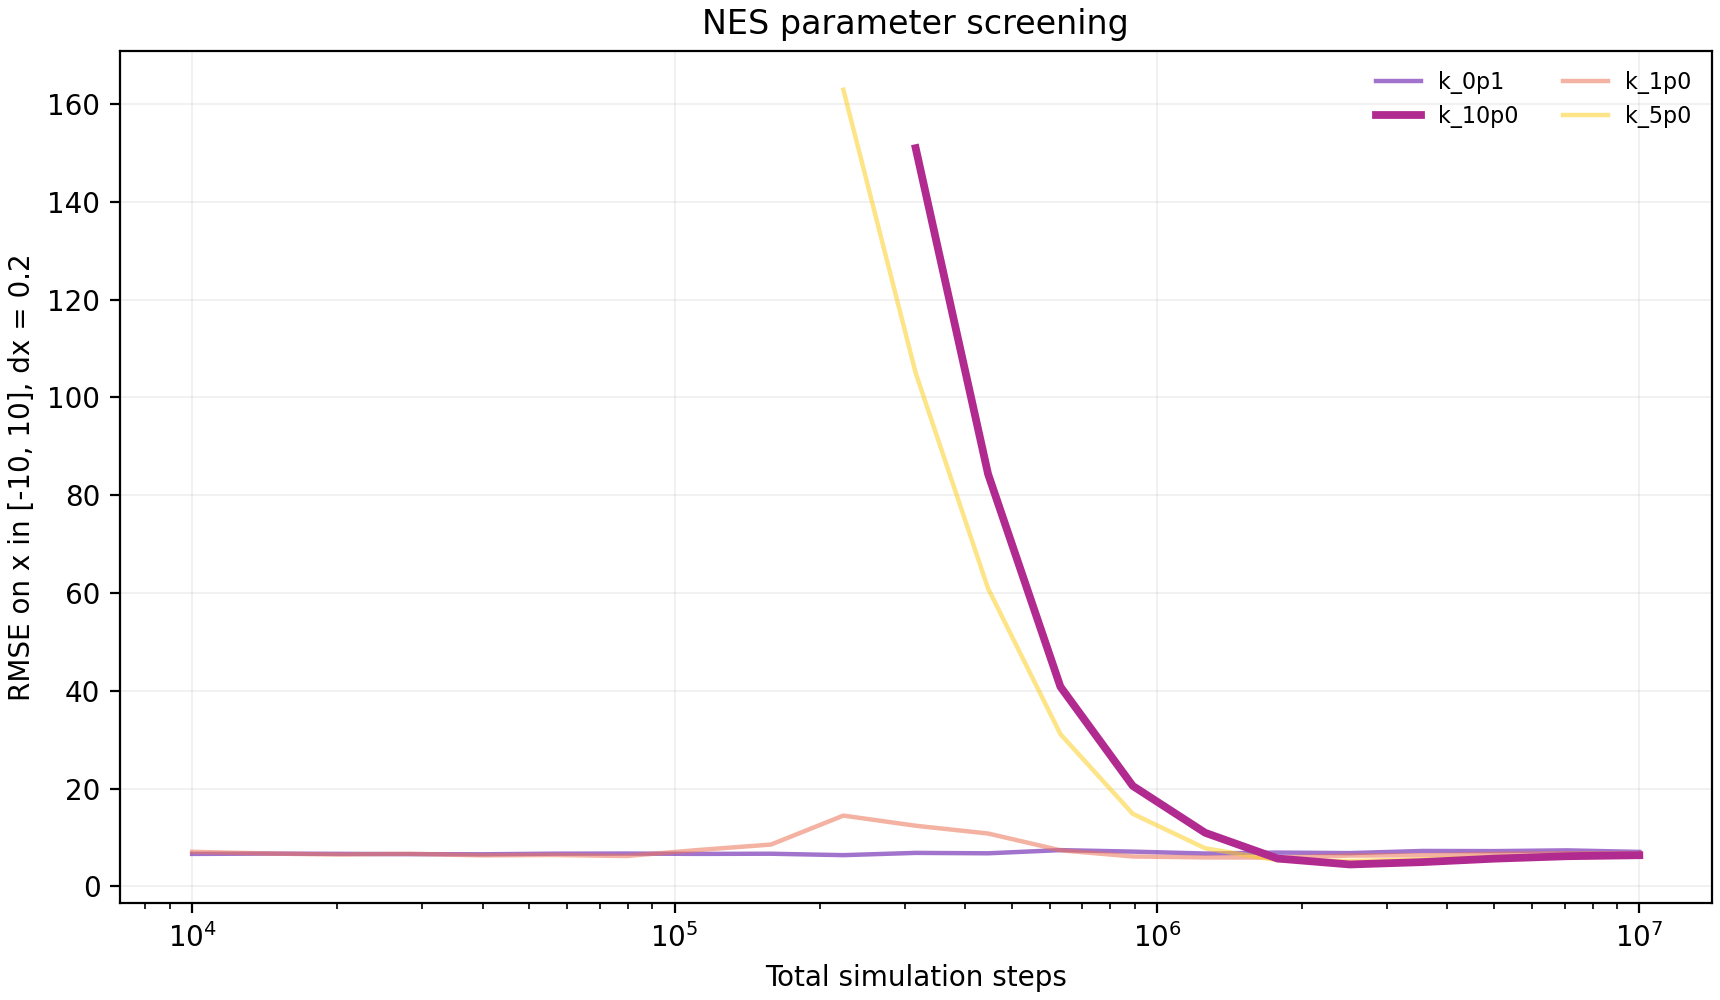

### MINES: RMSE vs time across screened parameters

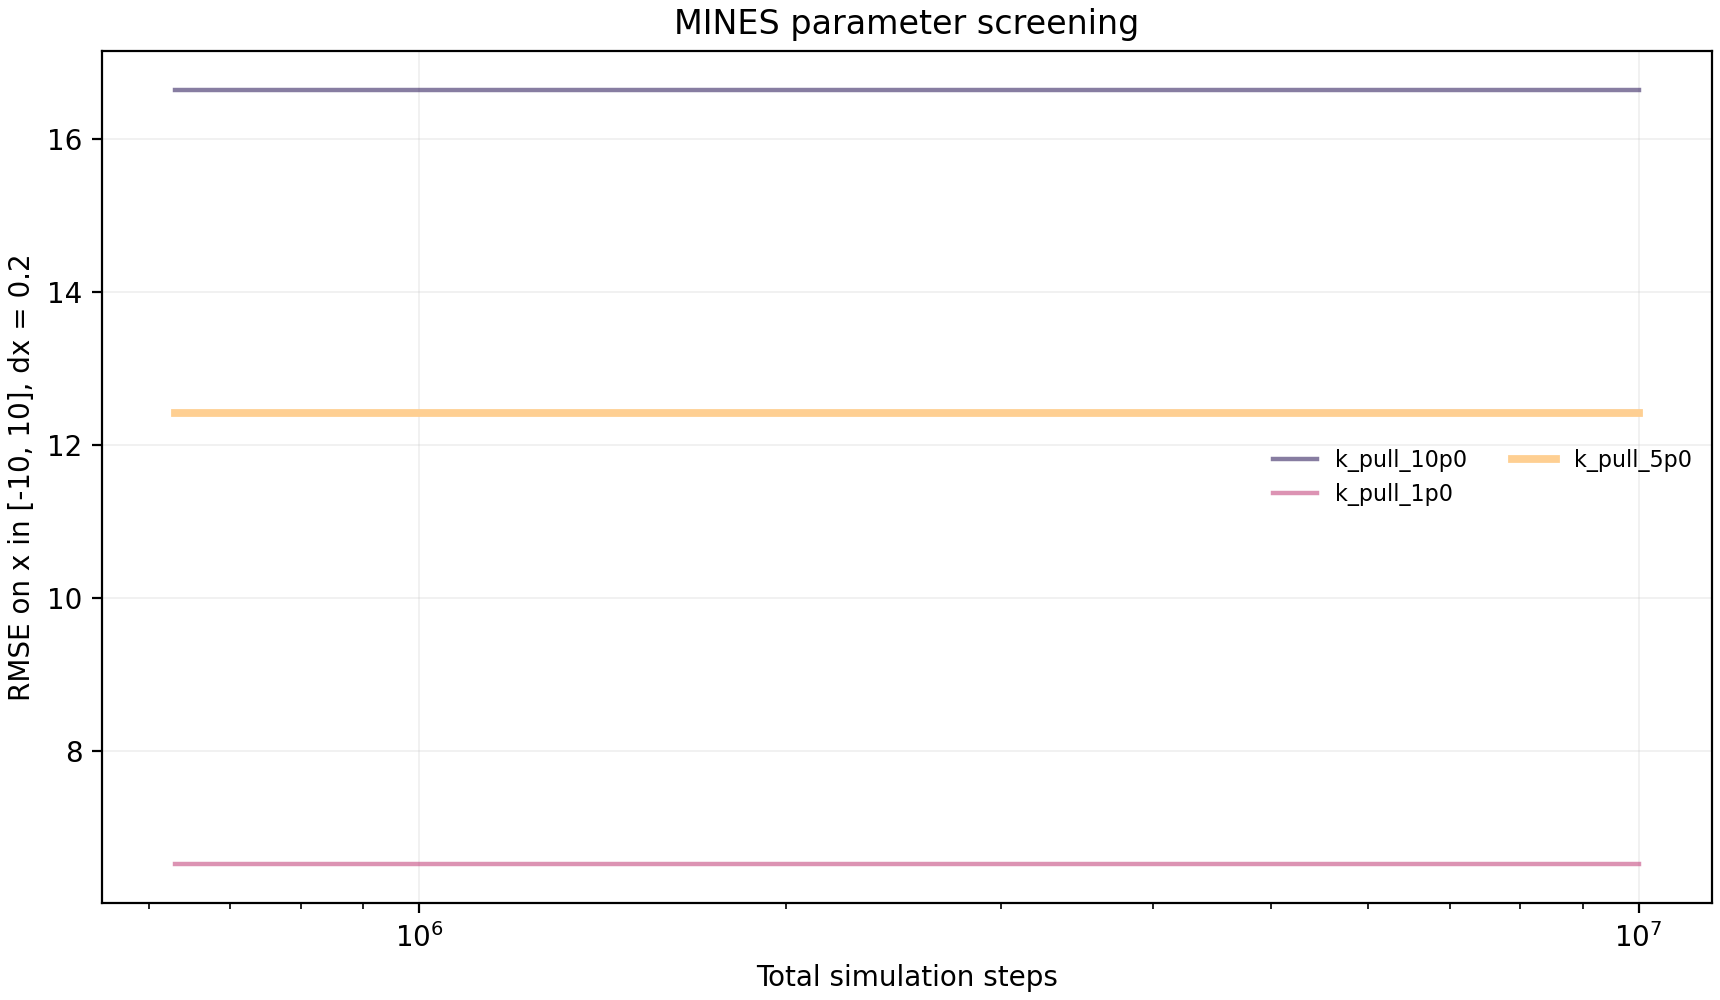

### MTD: RMSE vs time across screened parameters

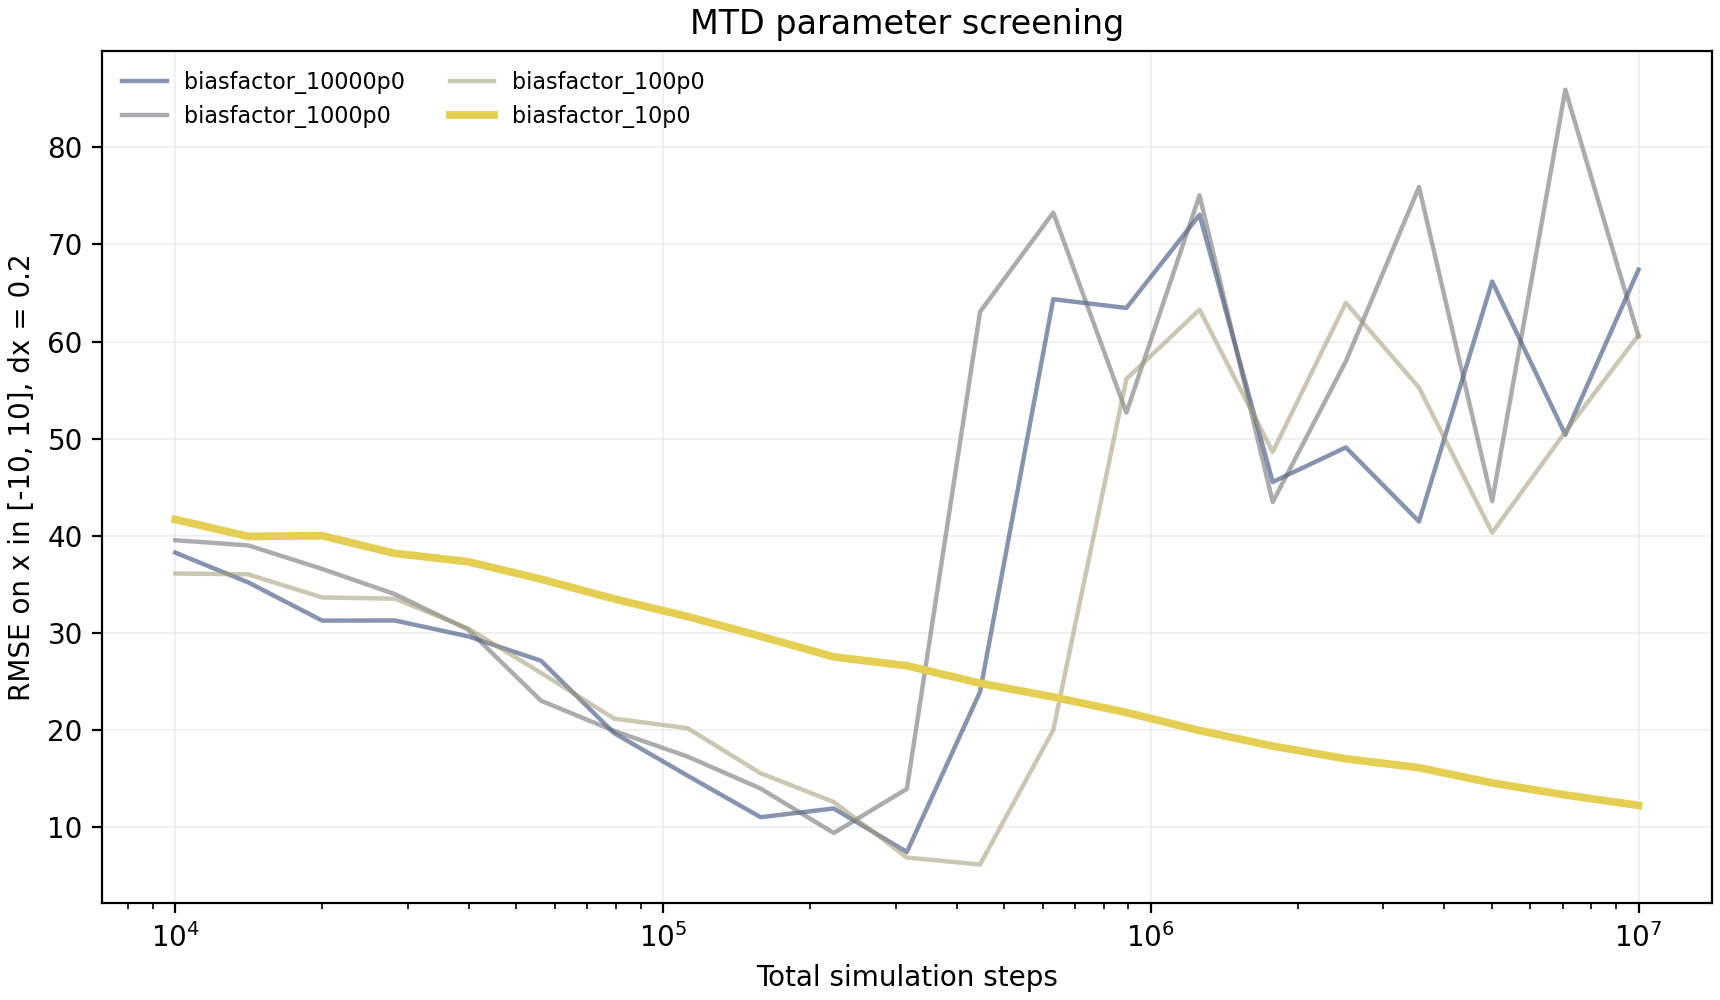

### Best RMSE comparison across methods

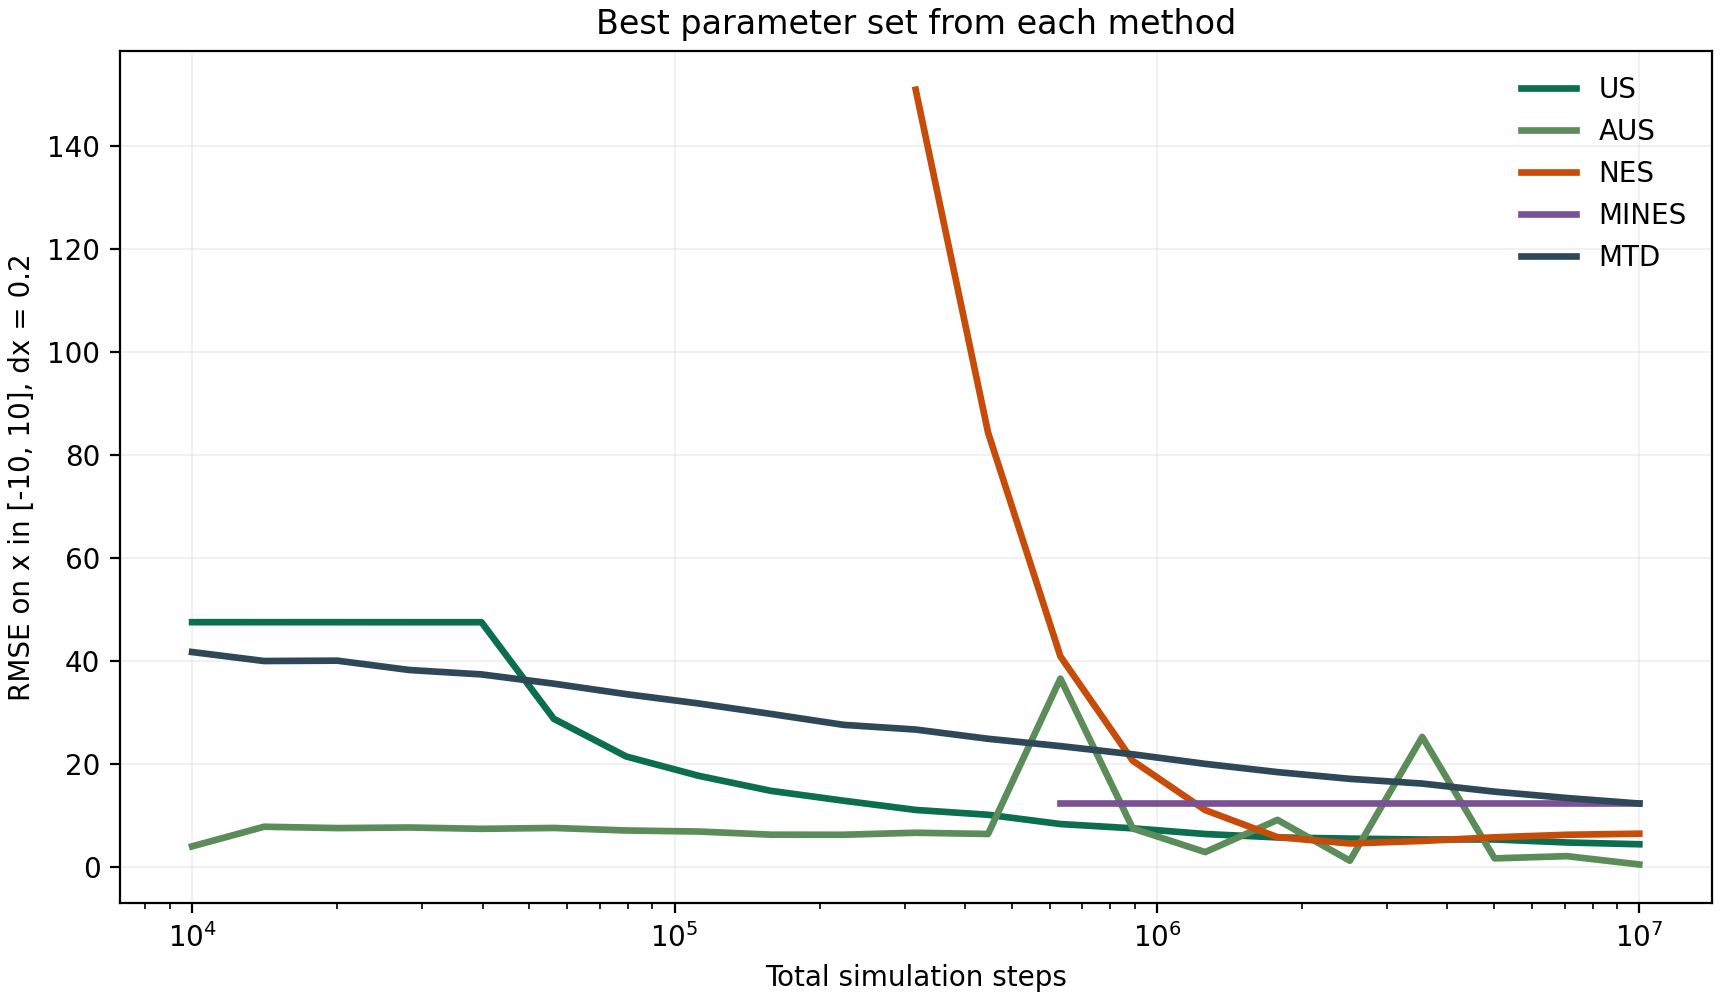

### Best final PMFs vs analytical solution

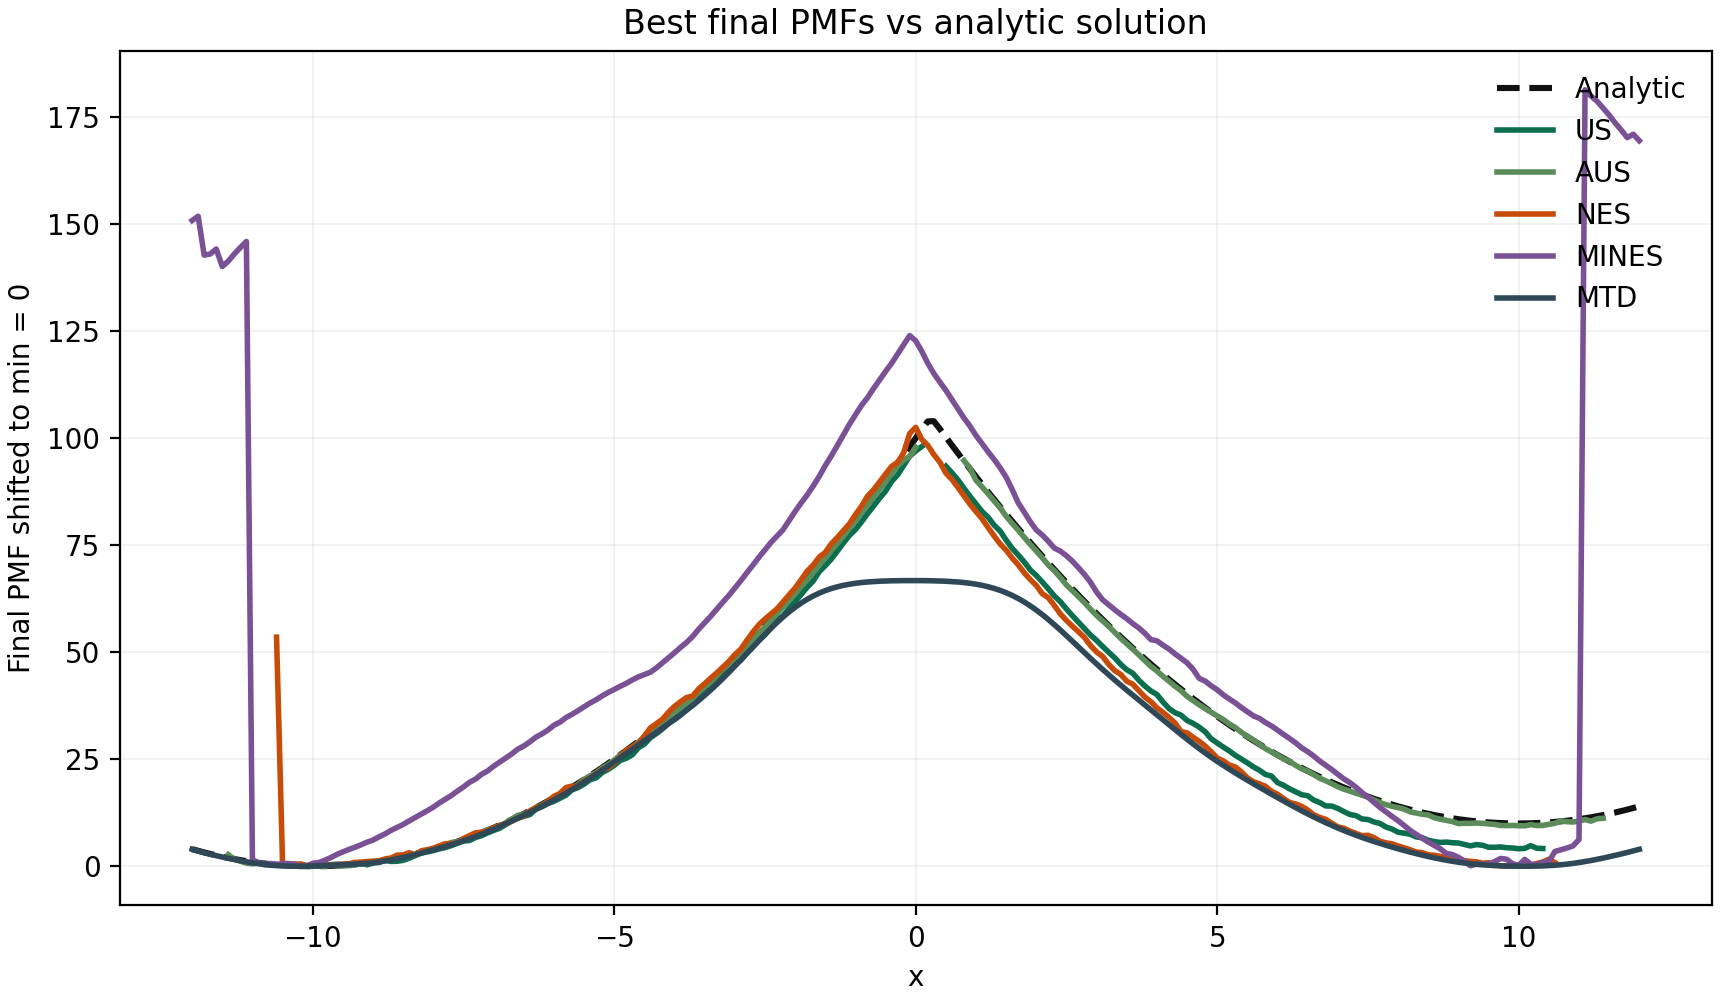

In [6]:
display(Markdown("## Convergence Figures"))
show_figure(FIGURES_ROOT / "doublewell_benchmark_us_rmse.png", "US: RMSE vs time across screened parameters")
show_figure(FIGURES_ROOT / "doublewell_benchmark_aus_rmse.png", "AUS: RMSE vs time across screened parameters")
show_figure(FIGURES_ROOT / "doublewell_benchmark_nes_rmse.png", "NES: RMSE vs time across screened parameters")
show_figure(FIGURES_ROOT / "doublewell_benchmark_mines_rmse.png", "MINES: RMSE vs time across screened parameters")
show_figure(FIGURES_ROOT / "doublewell_benchmark_mtd_rmse.png", "MTD: RMSE vs time across screened parameters")
show_figure(FIGURES_ROOT / "doublewell_benchmark_best_rmse.png", "Best RMSE comparison across methods")
show_figure(FIGURES_ROOT / "doublewell_benchmark_best_final_profiles.png", "Best final PMFs vs analytical solution")
